# Install & imports

In [1]:
# If needed:
# !pip install yfinance scikit-learn

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score


# Data: download Close prices & compute returns

In [3]:
# --- Config (edit these for your portfolio) ---
assets = ['AAPL', 'MSFT']        # tickers
weights = None                   # set to None for equal weights; or e.g., [0.6, 0.4]
start_date = "2018-01-01"
end_date   = "2025-01-01"

# --- Download Close prices ---
px = yf.download(assets, start=start_date, end=end_date)['Close']

# Ensure 2D DataFrame
if isinstance(px, pd.Series):
    px = px.to_frame()

# Daily returns (Close-to-Close)
returns = px.pct_change().dropna()

# Weights
if weights is None:
    weights = np.array([1.0/len(px.columns)] * len(px.columns))
else:
    weights = np.array(weights, dtype=float)
    weights = weights / weights.sum()  # normalize

print("Tickers:", list(px.columns))
print("Weights:", weights)
returns.tail()


C:\Users\mar_c\AppData\Local\Temp\ipykernel_19352\1743753796.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  px = yf.download(assets, start=start_date, end=end_date)['Close']
[*********************100%***********************]  2 of 2 completed

Tickers: ['AAPL', 'MSFT']
Weights: [0.5 0.5]


Ticker,AAPL,MSFT
Date,,
2024-12-24,0.011478,0.009374
2024-12-26,0.003176,-0.002777
2024-12-27,-0.013242,-0.017302
2024-12-30,-0.013263,-0.013240
2024-12-31,-0.007058,-0.007838


# Feature engineering & regime labels

In [ ]:
# ------------------------------------------------------------
# 1) VOLATILIDAD ROLLING (20 días) POR ACTIVO
# ------------------------------------------------------------

# Calcula la volatilidad diaria rolling de 20 días para cada activo
# returns: DataFrame (fechas x activos)
rolling_vol = returns.rolling(window=20, min_periods=20).std()

# ------------------------------------------------------------
# 2) VOLATILIDAD PROMEDIO DEL PORTAFOLIO
# ------------------------------------------------------------

# Promedia la volatilidad entre activos para cada día
# Resultado: Serie 1D que representa el "nivel de estrés" del mercado
avg_rolling_vol = rolling_vol.mean(axis=1)

# ------------------------------------------------------------
# 3) DEFINICIÓN DE REGÍMENES
# ------------------------------------------------------------

# Umbral simple: la media histórica de la volatilidad promedio
# (alternativa más robusta: usar percentiles, ej. 60% o 70%)
threshold = avg_rolling_vol.mean()

# Regímenes binarios:
# 0 = baja volatilidad
# 1 = alta volatilidad
regimes = (avg_rolling_vol > threshold).astype(int)

# ------------------------------------------------------------
# 4) CONSTRUCCIÓN DE FEATURES PARA CLASIFICAR REGÍMENES
# ------------------------------------------------------------

feat = pd.DataFrame({

    # Retorno promedio de corto plazo (5 días)
    # Se promedia entre activos para obtener una señal agregada
    'mean_return_5d': returns
        .rolling(window=5, min_periods=5)
        .mean()
        .mean(axis=1),

    # Volatilidad promedio de 20 días (ya calculada arriba)
    'volatility_20d': avg_rolling_vol,

    # Momentum de 10 días:
    # suma de retornos (aprox. retorno acumulado corto plazo)
    'momentum_10d': returns
        .rolling(window=10, min_periods=10)
        .sum()
        .mean(axis=1)
})

# ------------------------------------------------------------
# 5) LIMPIEZA Y ALINEACIÓN FINAL
# ------------------------------------------------------------

# Elimina filas con NaNs (por ventanas rolling)
features = feat.dropna()

# Alinea las etiquetas (regímenes) con las features
y = regimes.loc[features.index]

# ------------------------------------------------------------
# 6) INSPECCIÓN RÁPIDA
# ------------------------------------------------------------

# Umbral usado para separar baja vs alta volatilidad
print("Volatility threshold:", float(threshold))

# Conteo de observaciones en cada régimen
# (importante para ver si hay desbalance de clases)
print("Label counts:\n", y.value_counts())

# Muestra las últimas filas de las features
features.tail()

##Es el nivel promedio histórico de la volatilidad rolling (20 días).

# Regla usada:

# vol ≤ 0.0170 → régimen 0 (baja volatilidad)

# vol > 0.0170 → régimen 1 (alta volatilidad)

# 60% del tiempo el mercado estuvo en baja volatilidad

# 40% en alta volatilidad

Volatility threshold: 0.017037578092814077
Label counts:
 0    1046
1     695
Name: count, dtype: int64


,mean_return_5d,volatility_20d,momentum_10d
Date,,,
2024-12-24,-0.001413,0.010768,0.016876
2024-12-26,0.004525,0.010335,0.013275
2024-12-27,0.000851,0.010943,-0.005613
2024-12-30,-0.003582,0.011468,-0.016661
2024-12-31,-0.005069,0.011238,-0.034802


# Train the regime classifier (Random Forest)

In [6]:
# ------------------------------------------------------------
# 1) SPLIT DE DATOS EN TRAIN / TEST
# ------------------------------------------------------------

# Divide las observaciones en:
# - 80% entrenamiento
# - 20% prueba
#
# stratify=y asegura que ambos conjuntos
# mantengan la misma proporción de regímenes (0 / 1)
X_train, X_test, y_train, y_test = train_test_split(
    features,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ------------------------------------------------------------
# 2) DEFINICIÓN DEL MODELO
# ------------------------------------------------------------

# Random Forest Classifier:
# - modelo no lineal
# - robusto a ruido
# - bueno para detectar interacciones entre features
rf = RandomForestClassifier(
    n_estimators=300,        # número de árboles
    min_samples_leaf=2,     # regularización (evita overfitting)
    random_state=42,
    n_jobs=-1               # usa todos los cores disponibles
)

# Entrena el modelo con los datos históricos
rf.fit(X_train, y_train)

# ------------------------------------------------------------
# 3) EVALUACIÓN DEL MODELO
# ------------------------------------------------------------

# Accuracy:
# proporción de predicciones correctas (0 y 1)
acc = rf.score(X_test, y_test)

# Probabilidad predicha de estar en régimen de ALTA volatilidad
# predict_proba devuelve [P(clase 0), P(clase 1)]
proba_test = rf.predict_proba(X_test)[:, 1]

# ROC AUC:
# mide qué tan bien el modelo separa baja vs alta volatilidad
# independientemente del umbral de decisión
auc = roc_auc_score(y_test, proba_test)

# ------------------------------------------------------------
# 4) RESULTADOS
# ------------------------------------------------------------

print(f"Regime prediction accuracy: {acc:.2%}")
print(f"ROC AUC: {auc:.3f}")


Regime prediction accuracy: 100.00%
ROC AUC: 1.000


# Rolling volatility vs threshold; regime timeline

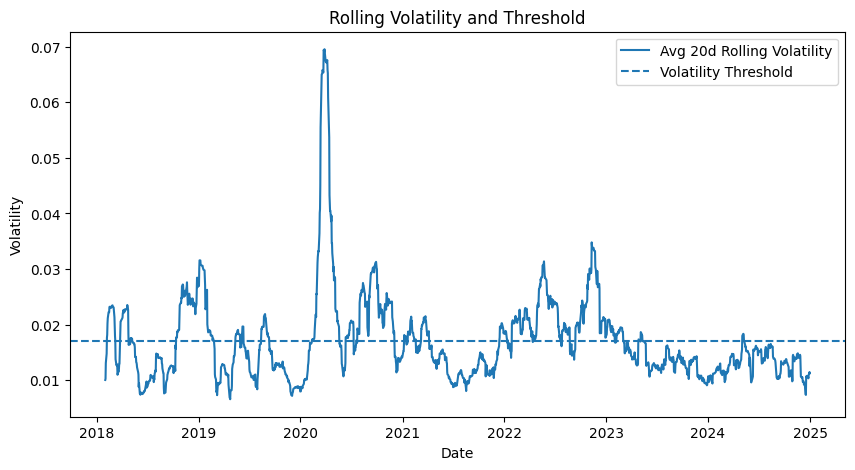

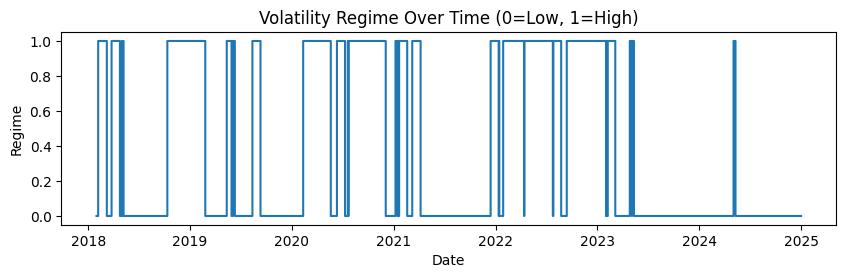

In [7]:
plt.figure(figsize=(10,5))
plt.plot(avg_rolling_vol.index, avg_rolling_vol.values, label='Avg 20d Rolling Volatility')
plt.axhline(threshold, linestyle='--', label='Volatility Threshold')
plt.title('Rolling Volatility and Threshold')
plt.xlabel('Date'); plt.ylabel('Volatility'); plt.legend(); plt.show()

plt.figure(figsize=(10,2.5))
plt.step(y.index, y.values, where='post')
plt.title('Volatility Regime Over Time (0=Low, 1=High)')
plt.xlabel('Date'); plt.ylabel('Regime'); plt.show()


# Feature importance (what drives predictions?)

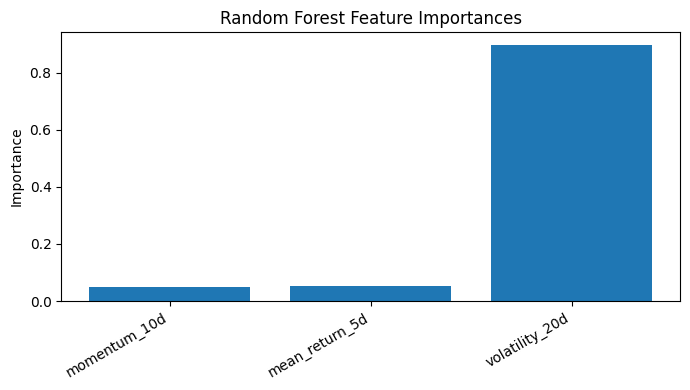

In [8]:
import numpy as np
importances = rf.feature_importances_
idx = np.argsort(importances)

plt.figure(figsize=(7,4))
plt.bar(range(len(idx)), importances[idx])
plt.xticks(range(len(idx)), np.array(features.columns)[idx], rotation=30, ha='right')
plt.title('Random Forest Feature Importances')
plt.ylabel('Importance'); plt.tight_layout(); plt.show()


# Probability separation (test set)

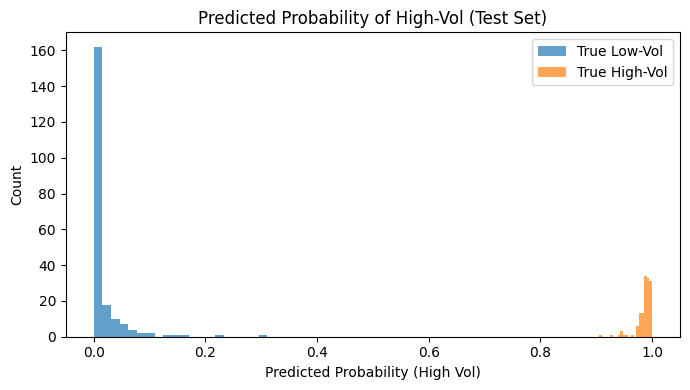

In [9]:
plt.figure(figsize=(7,4))
plt.hist(proba_test[y_test==0], bins=20, alpha=0.7, label='True Low-Vol')
plt.hist(proba_test[y_test==1], bins=20, alpha=0.7, label='True High-Vol')
plt.title('Predicted Probability of High-Vol (Test Set)')
plt.xlabel('Predicted Probability (High Vol)'); plt.ylabel('Count')
plt.legend(); plt.tight_layout(); plt.show()


# Standard Monte Carlo engine

In [10]:
# Portfolio stats from Close-price returns
mean_returns = returns.mean()
cov_matrix  = returns.cov()

def monte_carlo_simulation(mean_returns, cov_matrix, weights, num_simulations=50000, days=252, seed=42):
    rng = np.random.default_rng(seed)
    results = np.zeros(num_simulations)
    L = np.linalg.cholesky(cov_matrix)  # for stability & speed

    for i in range(num_simulations):
        # simulate daily multivariate normal via Cholesky
        Z = rng.standard_normal(size=(days, len(mean_returns)))
        simulated = Z @ L.T + mean_returns.values  # mean-shift
        port_daily = simulated @ weights
        results[i] = np.prod(1 + port_daily) - 1
    return results

standard_results = monte_carlo_simulation(mean_returns, cov_matrix, weights)


# AI‑Enhanced Monte Carlo (regime‑adaptive)

In [11]:
# Predict current regime from the latest row of features
current_X = features.iloc[[-1]]
predicted_regime = int(rf.predict(current_X)[0])
conf = rf.predict_proba(current_X)[0, predicted_regime]
print("Predicted regime:", "High Volatility" if predicted_regime==1 else "Low Volatility",
      f"(confidence ~ {conf:.1%})")

# Scale factors (tune for your use case or learn from data)
hi_scale = 1.5   # inflate cov in high-vol
lo_scale = 0.8   # deflate cov in low-vol

scale = hi_scale if predicted_regime == 1 else lo_scale
adjusted_cov = cov_matrix * scale

ai_results = monte_carlo_simulation(mean_returns, adjusted_cov, weights, seed=123)


Predicted regime: Low Volatility (confidence ~ 100.0%)


# Risk metrics & visual comparison

Standard MC: {'Mean Return': '34.23%', 'Prob(Loss)': '17.70%', 'VaR 95%': '-17.86%', 'CVaR 95%': '-26.48%'}
AI-Enhanced MC: {'Mean Return': '34.21%', 'Prob(Loss)': '14.16%', 'VaR 95%': '-13.63%', 'CVaR 95%': '-21.49%'}


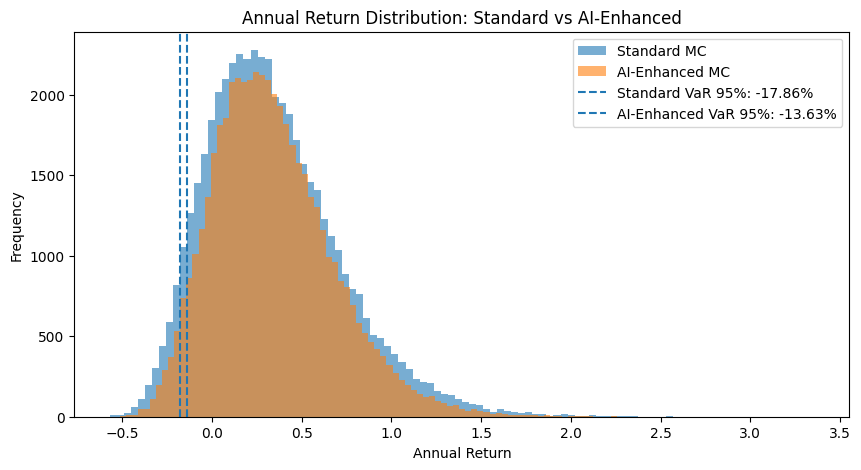

In [12]:
def risk_summary(sim_results):
    var95  = np.percentile(sim_results, 5)
    cvar95 = sim_results[sim_results <= var95].mean()
    prob_loss = (sim_results < 0).mean()
    mean_ret = sim_results.mean()
    return {
        "Mean Return": mean_ret,
        "Prob(Loss)": prob_loss,
        "VaR 95%": var95,
        "CVaR 95%": cvar95
    }

std_stats = risk_summary(standard_results)
ai_stats  = risk_summary(ai_results)

print("Standard MC:", {k: f"{v:.2%}" for k, v in std_stats.items()})
print("AI-Enhanced MC:", {k: f"{v:.2%}" for k, v in ai_stats.items()})

# Plot distributions together
plt.figure(figsize=(10,5))
plt.hist(standard_results, bins=100, alpha=0.6, label='Standard MC')
plt.hist(ai_results, bins=100, alpha=0.6, label='AI-Enhanced MC')
plt.axvline(np.percentile(standard_results, 5), linestyle='--', label=f'Standard VaR 95%: {np.percentile(standard_results,5):.2%}')
plt.axvline(np.percentile(ai_results, 5), linestyle='--', label=f'AI-Enhanced VaR 95%: {np.percentile(ai_results,5):.2%}')
plt.title('Annual Return Distribution: Standard vs AI-Enhanced')
plt.xlabel('Annual Return'); plt.ylabel('Frequency'); plt.legend(); plt.show()


# (Optional) Tuning regime balance

In [13]:
# Rebuild regimes with a stricter threshold (top 40% vol = High Vol)
threshold_q = avg_rolling_vol.quantile(0.6)
regimes_q = (avg_rolling_vol > threshold_q).astype(int)

# Rebuild features/y alignment quickly
features_q = feat.dropna()
y_q = regimes_q.loc[features_q.index]

X_train, X_test, y_train, y_test = train_test_split(
    features_q, y_q, test_size=0.2, random_state=42, stratify=y_q
)
rf_q = RandomForestClassifier(n_estimators=300, min_samples_leaf=2, random_state=42, n_jobs=-1)
rf_q.fit(X_train, y_train)

print("Accuracy (quantile regime):", f"{rf_q.score(X_test, y_test):.2%}")
print("AUC (quantile regime):", f"{roc_auc_score(y_test, rf_q.predict_proba(X_test)[:,1]):.3f}")


Accuracy (quantile regime): 99.71%
AUC (quantile regime): 1.000
